In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


In [2]:
data = pd.read_csv(r"C:\Users\DIVYA\OneDrive\Desktop\letsgo\practice1\python\diabetes.csv")

data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
X = data.drop("Outcome", axis =1)  #Inputs
y = data["Outcome"]                 #output label (0 or 1)

X_train, X_test, y_train, y_test= train_test_split(X, y , test_size=0.2, random_state= 42)

scaler = StandardScaler()                   #create scaler
X_train = scaler.fit_transform(X_train)     #fit and scale training data
X_test = scaler.transform(X_test)           #scale the data

In [30]:
from tensorflow.keras import Input

model = Sequential()
model.add(Input(shape = (X_train.shape[1],))) #First layer is Input layer
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(8, activation='relu'))
 
model.add(Dense(1, activation='sigmoid'))
 

In [31]:
#compiling the model

model.compile(
    loss = 'binary_crossentropy',
    optimizer = 'adam',
    metrics =['accuracy']
)

In [32]:
history = model.fit(
    X_train,
    y_train,
    epochs =150,
    batch_size = 32,
    validation_split = 0.2,
    verbose =1

)

Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.3768 - loss: 0.7237 - val_accuracy: 0.4715 - val_loss: 0.6932
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5499 - loss: 0.6909 - val_accuracy: 0.6748 - val_loss: 0.6740
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6802 - loss: 0.6715 - val_accuracy: 0.7236 - val_loss: 0.6579
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7006 - loss: 0.6499 - val_accuracy: 0.7073 - val_loss: 0.6416
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7128 - loss: 0.6268 - val_accuracy: 0.6992 - val_loss: 0.6254
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7210 - loss: 0.6071 - val_accuracy: 0.7073 - val_loss: 0.6068
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7312 - loss: 0.5847 - val_accuracy: 0.7236 - val_loss: 0.5845
Epoch 8/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7393 - loss: 0.5543 - val_accuracy: 0.7317 - 

#### Evaluate the ANN Model using Test Data (Confusion Matrix + Accuracy)

In [33]:
#predict the class labels for x_test
y_pred_prob = model.predict(X_test)

#convert probabilities to class labels(0 or 1)
y_pred = (y_pred_prob >0.5).astype(int)

#confusion matrix and accuracy
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

#print results
print("Confusion Matrix:\n",cm)
print("Test Accuracy:", acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Confusion Matrix:
 [[77 22]
 [18 37]]
Test Accuracy: 0.7402597402597403


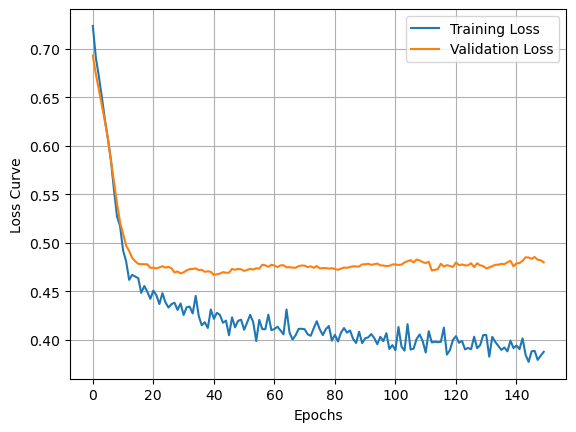

In [34]:
#plot training loss and validation loss
plt.plot(history.history['loss'], label ='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

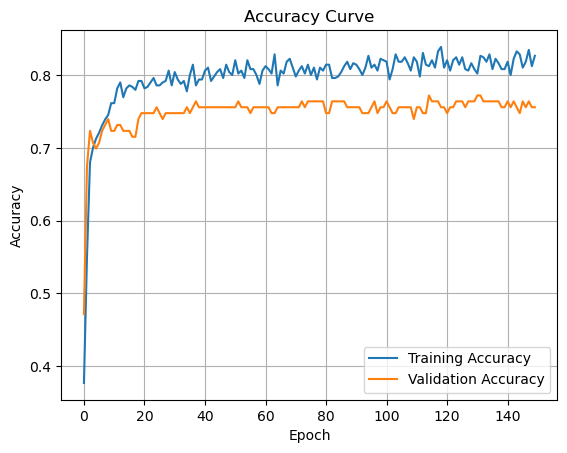

In [35]:
#plot training accuracy and validation accuracy
plt.plot(history.history['accuracy'], label ='Training Accuracy')
plt.plot(history.history['val_accuracy'], label ='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()

### Hyperparameter Tuning + Regularization

#### First Subpoint :choosing Layers and Neurons
#### Second Subpoint : choosing Activation functions
#### third subpoint : choosing Learning rate, Epochs, Batch Size
#### Fourth subpoint : Overfitting - Dropout, EarlyStopping , L2 Regularization